# Figure 2: Visualizations at the fragment level

## Library imports

If you are using this Jupyter notebook in **Binder** (the lightest version with the already saved data required for plot reproduction), we recommend commenting out and running the box below to install all the necessary Python packages needed to make this notebook work. 

In [6]:
## Install all necessary Python packages directly in the notebook
!pip install numpy pandas numba tqdm plotly alphatims scikit-learn pyarrow holoviews datashader jupyter_bokeh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.3 MB/s eta 0:00:00


In [1]:
import pandas as pd

import ext.utils as utils
import ext.fig2_functions as fig2
import alphatims.bruker
import jupyter_bokeh

### Supplementary functions

Please run all cells below to import the functions required for data analysis and visualisation.

## Fig 2A: MS2 DDA spectra 

**For this figure we used the file `20190124_QX3_JuSc_SA_JS7_1_wt_4h_1.raw` from the [PXD012867 PRIDE project](https://www.ebi.ac.uk/pride/archive/projects/PXD012867).**

* To simplify this step and reproduce it on Binder, load the dataframe `df_ms2` where one scan (#20385) has already been saved in a parquet file for you. 

In [2]:
df_ms2 = pd.read_parquet('Data/20190124_QX3_JuSc_SA_JS7_1_wt_4h_1_ms2_data', engine='pyarrow')
df_ms2.head()

,scan,prec_mono_mz,prec_charge,mz_values,intensity_values
0,20385,828.8599,2,"[110.07135772705078, 129.06614685058594, 129.1...","[51561, 8473, 136287, 95265, 10150, 24818, 179..."


**To work with the entire file in the Jupyter notebook on your PC, please download the specified file from the PRIDE repository and change the path to it on your PC. To do this, comment out and run the code below.**

* **Troubleshooting**: In case you get the error "ModuleNotFoundError: No module named 'pyrawfilereader'" while running this cell, please refer to the Notebook documentation for Figure 1 (Figure 1 - precursor level visualisation) on how to read Thermo raw data on your computer.

In [3]:
# ms2_dda_path = '.../Data/PXD012867_yeast_project/20190124_QX3_JuSc_SA_JS7_1_wt_4h_1.raw'

# ms2_dda_data = utils.load_thermo_raw(ms2_dda_path)
# df_ms2 = pd.DataFrame(
#     {'scan': ms2_dda_data['scan_list_ms2'], 
#     'prec_mono_mz': ms2_dda_data['mono_mzs2'],
#     'prec_charge': ms2_dda_data['charge_ms2'],
#     'mz_values': ms2_dda_data['mass_list_ms2'],
#     'intensity_values': ms2_dda_data['int_list_ms2']
#     }
# )
# df_ms2.head()

**From `evidence.txt` (MaxQuant output file) we decided to select a peptide with a high Andromeda score and look at its raw data. For this purpose, we chose `NTINHNLNDDEDK` peptide of the protein `Q12515` with `m/z = 828.85844`, `charge = 2`, `RT = 17.797 min`.**
* To simplify the data loading process, we took the `msms.txt` file from the original Pride repository and saved it in the Data folder filtered for only one experiment, `20190124_QX3_JuSc_SA_JS7_1_wt_4h_1`.

In [4]:
peptide_fig2a = {
    'sequence': 'NTINHNLNDDDEDK',
    'm/z': 828.85844,
    'charge': 2,
    'CE': 27,
    'scan_number': 20385,
    'rt': 17.797 #min
}

In [5]:
data = fig2.data_preprocessing(
    ms2_data=df_ms2,
    path_to_msms_file='Data/20190124_QX3_JuSc_SA_JS7_1_wt_4h_1_msms.txt',
    scan_number=peptide_fig2a['scan_number'],
    exp_name='20190124_QX3_JuSc_SA_JS7_1_wt_4h_1'
)

The structure of the dataframe for the selected scan number 20385 and the experiment 20190124_QX3_JuSc_SA_JS7_1_wt_4h_1 with the fragment type and fragment m/z columns.
  frag_type     frag_mz
0        y1  147.112804
1        y2  262.140075
2        y3  391.182626
3        y4  506.209188
4        y5  621.234977


The sliced ms2 raw data for the selected scan number 20385.
    mz_values  intensity_values ions
0  110.071358             51561     
1  129.066147              8473     
2  129.102249            136287     
3  130.086136             95265     
4  134.487762             10150     


The list of unique ions assigned to the raw data spectrum.
['', 'y1-NH3', 'y1', 'a2', 'b2-H2O', 'b2', 'y2-H2O', 'y2-NH3', 'y2', 'b3-H2O', 'b3', 'y3-H2O', 'y3', 'b4-H2O', 'b4-NH3', 'b4', 'y4-H2O', 'y4', 'b5-H2O', 'b5-NH3', 'b5', 'y5', 'y6', 'y7-NH3', 'y7', 'y8', 'b9', 'y9-NH3', 'y9', 'b10-NH3', 'b10', 'y10-H2O', 'y10-NH3', 'y10', 'b11-NH3', 'b11', 'y11-H2O', 'y11', 'b12', 'b13-NH3', 'b13']


**To manually evaluate the MS2 spectra and the identifications based on them, one can look at the individual MS2 spectra, highlighting the N-terminal and C-terminal fragment ions of the single selected precursor. Underneath the spectrum itself, the sequence of the identified peptide and the position of identified N/C terminal fragment ions are indicated.**

In [6]:
fig2.plot_mass_spectra(
    data=data, 
    title=f"MS2 DDA spectrum for peptide {peptide_fig2a['sequence']}: m/z = {peptide_fig2a['m/z']:.3f} and charge {peptide_fig2a['charge']}.",
    sequence=peptide_fig2a['sequence'],
).show(config=utils.config)

%opts magic unavailable (pyparsing cannot be imported)
%compositor magic unavailable (pyparsing cannot be imported)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

**Issues that can become apparent here are co-fragmentation of several peptides (many more fragments visible) or other isotopes of the same peptide (isotopic clusters for fragments), or poor fragmentation (very few ions and intense precursor peak).**

## Fig 2 B: Mirrored spectra 

**For this figure we used the same file as for the Fig 2A (`20190124_QX3_JuSc_SA_JS7_1_wt_4h_1.raw` file from [PXD012867 PRIDE project](https://www.ebi.ac.uk/pride/archive/projects/PXD012867)).**

* To simplify this step and reproduce it on Binder, load the dataframe `df_ms2` where one scan (#20385) has already been saved in a parquet file for you. 

In [7]:
df_ms2 = pd.read_parquet('Data/20190124_QX3_JuSc_SA_JS7_1_wt_4h_1_ms2_data', engine='pyarrow')
df_ms2.head()

,scan,prec_mono_mz,prec_charge,mz_values,intensity_values
0,20385,828.8599,2,"[110.07135772705078, 129.06614685058594, 129.1...","[51561, 8473, 136287, 95265, 10150, 24818, 179..."


**To work with the entire file in the Jupyter notebook on your PC, please download the specified file from the PRIDE repository and change the path to it on your PC. To do this, comment out and run the code below.**

* **Troubleshooting**: In case you get the error "ModuleNotFoundError: No module named 'pyrawfilereader'" while running this cell, please refer to the Notebook documentation for Figure 1 (Figure 1 - precursor level visualisation) on how to read Thermo raw data on your computer.

In [8]:
# ms2_dda_path = '.../Data/PXD012867_yeast_project/20190124_QX3_JuSc_SA_JS7_1_wt_4h_1.raw'

# ms2_dda_data = utils.load_thermo_raw(ms2_dda_path)
# df_ms2 = pd.DataFrame(
#     {'scan': ms2_dda_data['scan_list_ms2'], 
#     'RT': ms2_dda_data['rt_list_ms2'],
#     'prec_mono_mz': ms2_dda_data['mono_mzs2'],
#     'prec_charge': ms2_dda_data['charge_ms2'],
#     'mz_values': ms2_dda_data['mass_list_ms2'],
#     'intensity_values': ms2_dda_data['int_list_ms2'],
#     'order': 'ms2'}
# )
# df_ms2.head()

**Consider the same `NTINHNLNDDEDK` peptide of the `Q12515` protein used for Fig 2A.**

* To simplify the data loading process, we took the `msms.txt` file from the original Pride repository and saved it in the Data folder filtered for only one experiment, `20190124_QX3_JuSc_SA_JS7_1_wt_4h_1`.

In [9]:
data_fig2b = fig2.data_preprocessing(
    ms2_data=df_ms2,
    path_to_msms_file='Data/20190124_QX3_JuSc_SA_JS7_1_wt_4h_1_msms.txt',
    scan_number=peptide_fig2a['scan_number'],
    exp_name='20190124_QX3_JuSc_SA_JS7_1_wt_4h_1',
    relative_intensity=True
)

The structure of the dataframe for the selected scan number 20385 and the experiment 20190124_QX3_JuSc_SA_JS7_1_wt_4h_1 with the fragment type and fragment m/z columns.
  frag_type     frag_mz
0        y1  147.112804
1        y2  262.140075
2        y3  391.182626
3        y4  506.209188
4        y5  621.234977


The sliced ms2 raw data for the selected scan number 20385.
    mz_values  intensity_values ions
0  110.071358          7.862425     
1  129.066147          0.171531     
2  129.102249         22.985398     
3  130.086136         15.663270     
4  134.487762          0.470864     


The list of unique ions assigned to the raw data spectrum.
['', 'y1-NH3', 'y1', 'a2', 'b2-H2O', 'b2', 'y2-H2O', 'y2-NH3', 'y2', 'b3-H2O', 'b3', 'y3-H2O', 'y3', 'b4-H2O', 'b4-NH3', 'b4', 'y4-H2O', 'y4', 'b5-H2O', 'b5-NH3', 'b5', 'y5', 'y6', 'y7-NH3', 'y7', 'y8', 'b9', 'y9-NH3', 'y9', 'b10-NH3', 'b10', 'y10-H2O', 'y10-NH3', 'y10', 'b11-NH3', 'b11', 'y11-H2O', 'y11', 'b12', 'b13-NH3', 'b13']


**A mirror predicted MS2 spectrum was generated using the [Prosit_2020_intensity_hcd](https://doi.org/10.1038/s41592-019-0426-7) model on the https://www.proteomicsdb.org/prosit/ platform. For this, the peptide was saved in a .csv file (`Data/prosit_prediction.csv`) with its amino acid sequence, CE and charge.  Select `Generic Text' for the output format.**

* If you wish to reproduce this step for any other peptide, change the `peptide_fig2b` dictionary and comment out the following cell to save the .csv file.

In [10]:
# pd.DataFrame.from_dict(data={
#     'modified_sequence': [peptide_fig2a['sequence']], 
#     'collision_energy': [peptide_fig2a['CE']], 
#     'precursor_charge': [peptide_fig2a['charge']]
# }).to_csv('Data/prosit_prediction.csv', index=False)

**When you receive the predicted file (`Data/myPrositLib.csv`), you can load it and extract the predicted fragment ions and their intensities.**

In [11]:
path_to_prediction = 'Data/myPrositLib.csv'

predicted_df = fig2.preprocess_prediction(
    path=path_to_prediction, 
    peptide_sequence=peptide_fig2a['sequence']
)

The structure of the dataframe for the predicted peptide NTINHNLNDDDEDK using Prosit model.
    RelativeIntensity  FragmentMz StrippedPeptide  FragmentNumber  \
0          -44.848627   147.11281  NTINHNLNDDDEDK               1   
4          -80.177070   262.13974  NTINHNLNDDDEDK               2   
6          -78.444110   216.09789  NTINHNLNDDDEDK               2   
8          -45.272386   391.18234  NTINHNLNDDDEDK               3   
10         -39.689818   329.18195  NTINHNLNDDDEDK               3   

   FragmentType  FragmentCharge FragmentLossType ions  
0             y               1           noloss   y1  
4             y               1           noloss   y2  
6             b               1           noloss   b2  
8             y               1           noloss   y3  
10            b               1           noloss   b3  


**To check the quality of the peptide-spectrum-match against the predicted library, mirrored spectra plot can be used. Here the theoretical fragment masses are shown on a mirrored y-axis.**

In [12]:
fig2.plot_mass_spectra(
    data=data_fig2b, 
    predicted=(predicted_df.FragmentMz, predicted_df.RelativeIntensity, predicted_df.ions),
    title=f"Experimental and predicted spectrum for {peptide_fig2a['sequence']}: m/z = {peptide_fig2a['m/z']:.3f} and charge {peptide_fig2a['charge']}.",
    sequence=peptide_fig2a['sequence'],
).show(config=utils.config)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

**The plot demonstrates which fragments are missing or should correctly be identified in the measured spectrum. In this case the number of fragments is crutial as well their relative intensities that can reveal e.g. fragmentation issues.**

## Fig 2C & Fig 2D

**For the `2C` and `2D` figures we used the raw Bruker file from [Project PXD017703 from ProteomeXchange](https://www.ebi.ac.uk/pride/archive/projects/PXD017703) as example data.**

* To read the raw TIMS-TOF data we used the recently published package [AlphaTims](https://github.com/MannLabs/alphatims).

**! IMPORTANT. To obtain the same plots as shown in the review please read the Bruker data with AlphaTims on Windows or Linux OS.**

**Due to the large size of the file `it is not possible` to perform this step on Binder. To reproduce it, please run it on a local Windows or Linux machine.**

In [2]:
bruker_file_path = './Data/HeLa_Evosep_diaPASEF_RAW/60SPD_py8/20200428_Evosep_60SPD_SG06-16_MLHeLa_200ng_py8_S3-A6_1_2452.d'
bruker_raw_data = alphatims.bruker.TimsTOF(bruker_file_path)

100%|██████████| 11872/11872 [00:18<00:00, 637.49it/s]


**Consider the following peptide (peptide information was taken from the file `pyprophet_export_60SPD.tsv`):**

* sequence: "IIIPEIQK"
* charge: 2
* m/z: 477.3051, Th
* im: 0.86, 1/K0
* rt: 703.802, seconds

![image](https://i.gyazo.com/a66e3676aa75dff9834d4acee7538b94.png)

In [3]:
peptide_fig2cd = {
    "sequence": "IIIPEIQK",
    "charge": 2,
    "mz": 477.3051,
    "im": 0.86,
    "rt": 703.802      
}

## Fig 2C: Precursor/fragments elution profile 

**To assess the quality of DIA identifications we can visualize the elution profiles of all fragments associated with a specific precursor. Ideally, they should form a single sharp peak together with the precursor.**

%opts magic unavailable (pyparsing cannot be imported)
%compositor magic unavailable (pyparsing cannot be imported)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

/home/hreza/miniconda3/envs/prot_vis/lib/python3.8/site-packages/numba/core/ir_utils.py:2172: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'parsed_pep' of function 'get_fragmass'.

For more information visit https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "ext/utils.py", line 239:
@njit
def get_fragmass(parsed_pep:list, mass_dict:numba.typed.Dict)->tuple:
^

  warnings.warn(NumbaPendingDeprecationWarning(msg, loc=loc))


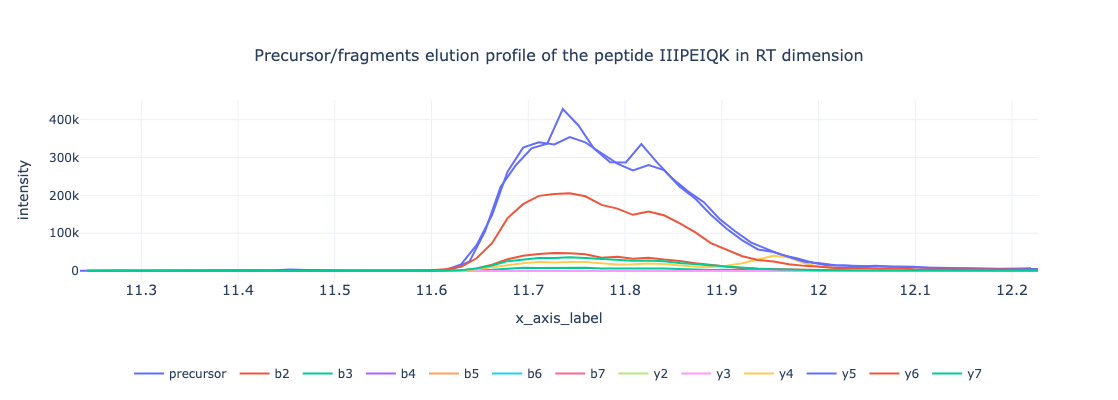

In [4]:
fig2.plot_elution_profile(
    bruker_raw_data, 
    peptide_fig2cd,
    fig2.mass_dict,
    title=f"Precursor/fragments elution profile of the peptide {peptide_fig2cd['sequence']} in RT dimension"
).show(config=utils.config)

**The shape of the elution peak in this case is correlated between fragments (b2,b3,y4-y7 ions). A problem that can be detected using this type of plot is, for example, peak misassignment. In this case we may see peak shifts or blending of additional peaks of individual fragments.**

## Fig 2D: Precursor/fragments elution profile in 3D dimension (RT vs. IM)

**With an additional ion mobility dimension in the Bruker data, we can visualise elution profile plots for each fragment separately in 3D dimension. This leads to higher confidence, as fragments should correlate along this dimension as well. Both dimensions together can be visualized in heatmaps for the precursor and all its fragments in retention time and ion mobility space, colored by intensity.**

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
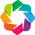

:Layout
   .DynamicMap.I    :DynamicMap   []
      :RGB   [rt_values,mobility_values]   (R,G,B,A)
   .DynamicMap.II   :DynamicMap   []
      :RGB   [rt_values,mobility_values]   (R,G,B,A)
   .DynamicMap.III  :DynamicMap   []
      :RGB   [rt_values,mobility_values]   (R,G,B,A)
   .DynamicMap.IV   :DynamicMap   []
      :RGB   [rt_values,mobility_values]   (R,G,B,A)
   .DynamicMap.V    :DynamicMap   []
      :RGB   [rt_values,mobility_values]   (R,G,B,A)
   .DynamicMap.VI   :DynamicMap   []
      :RGB   [rt_values,mobility_values]   (R,G,B,A)
   .DynamicMap.VII  :DynamicMap   []
      :RGB   [rt_values,mobility_values]   (R,G,B,A)
   .DynamicMap.VIII :DynamicMap   []
      :RGB   [rt_values,mobility_values]   (R,G,B,A)
   .DynamicMap.IX   :DynamicMap   []
      :RGB   [rt_values,mobility_values]   (R,G,B,A)
   .DynamicMap.X    :DynamicMap   []
      :RGB   [rt_values,mobility_values]   (R,G,B,A)
   .DynamicMap.XI   :DynamicMap   []
      :RGB   [rt_values,mobility_values]   (R,G,B,A)
   .DynamicMap.XII  :DynamicMap   []
      :RGB   [rt_values,mobility_values]   (R,G,B,A)
   .DynamicMap.XIII :DynamicMap   []
      :RGB   [rt_values,mobility_values]   (R,G,B,A)

In [5]:
fig2.plot_elution_profile_heatmap(
    bruker_raw_data, 
    peptide_fig2cd,
    fig2.mass_dict
)

**This plot confirms the results we saw in figure 2c using the 2D elution profiles for the selected peptides.  In this case we clearly observe strong evidences in the raw data for b2, b3, y4-y7 ions.**